# Spatial VQ-VAE Variant (DeMemte)

Variante basada en **Spatial ConvVAE**, reemplazando el bloque variacional continuo por **VQ-VAE espacial** con codebook EMA.

Objetivos:
- Usar `d_q = ||z_e - z_q||^2` como señal de familiaridad.
- Hacer compuerta por muestra (no por batch global) para estabilidad.
- Entrenar en **feature-space denoising**: `input=noisy_feats`, `target=clean_feats`.

## 1) Environment Setup and Imports

In [1]:
# Si falta algo, descomenta:
# !pip install torch torchvision matplotlib

import os
import copy
import json
import random
from dataclasses import dataclass, asdict
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda: True


## 2) Project Configuration and Constants

In [2]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 64
    num_workers: int = 2

    # Entrenamiento
    epochs_phase1: int = 3
    epochs_phase2: int = 3
    lr_vq: float = 3e-4
    lr_cls: float = 1e-3
    weight_decay: float = 1e-4

    # Ruido en feature-space (Option B)
    feature_noise_std: float = 0.35

    # VQ-VAE
    embedding_dim: int = 128
    num_embeddings: int = 512
    commitment_cost: float = 0.25
    ema_decay: float = 0.99
    eps: float = 1e-5

    # Gate por familiaridad
    init_tau: float = 0.0
    init_alpha: float = 1.5
    init_memory_scale: float = 1.0

    # Pérdidas
    denoise_weight: float = 1.0
    vq_weight: float = 1.0

    # Debug
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    max_train_batches_debug: int = 20
    max_val_batches_debug: int = 10

cfg = Config()
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 64,
  "num_workers": 2,
  "epochs_phase1": 3,
  "epochs_phase2": 3,
  "lr_vq": 0.0003,
  "lr_cls": 0.001,
  "weight_decay": 0.0001,
  "feature_noise_std": 0.35,
  "embedding_dim": 128,
  "num_embeddings": 512,
  "commitment_cost": 0.25,
  "ema_decay": 0.99,
  "eps": 1e-05,
  "init_tau": 0.0,
  "init_alpha": 1.5,
  "init_memory_scale": 1.0,
  "denoise_weight": 1.0,
  "vq_weight": 1.0,
  "device": "cuda",
  "max_train_batches_debug": 20,
  "max_val_batches_debug": 10
}


## 3) Input Loading and Preprocessing

In [3]:
def build_dataloaders(config: Config):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    trainset = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=False, transform=transform_train)
    valset = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=False, transform=transform_eval)
    testset = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=False, transform=transform_eval)

    trainloader = DataLoader(trainset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
    valloader = DataLoader(valset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    testloader = DataLoader(testset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return trainloader, valloader, testloader

trainloader, valloader, testloader = build_dataloaders(cfg)
xb, yb = next(iter(trainloader))
print('batch x:', tuple(xb.shape), 'batch y:', tuple(yb.shape))

batch x: (64, 3, 224, 224) batch y: (64,)


## 4) Core Function/Class Implementation

In [4]:
def make_spatial_backbone():
    """ResNet18 truncado para obtener feature map [B, 512, 7, 7]."""
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    body = list(base.children())[:-2]
    return nn.Sequential(*body)


class VectorQuantizerEMA(nn.Module):
    """Vector Quantization con codebook EMA para evitar collapse."""
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float = 0.25,
                 decay: float = 0.99, eps: float = 1e-5):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.eps = eps

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

        self.register_buffer('ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('ema_w', self.embedding.weight.data.clone())

    def forward(self, z_e: torch.Tensor):
        # z_e: [B, C, H, W], C=embedding_dim
        b, c, h, w = z_e.shape
        assert c == self.embedding_dim

        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()      # [B,H,W,C]
        flat = z_e_perm.view(-1, c)                           # [N,C]

        emb = self.embedding.weight                           # [K,C]
        distances = (
            flat.pow(2).sum(dim=1, keepdim=True)
            - 2 * flat @ emb.t()
            + emb.pow(2).sum(dim=1, keepdim=True).t()
        )

        encoding_indices = torch.argmin(distances, dim=1)     # [N]
        encodings = F.one_hot(encoding_indices, self.num_embeddings).type(flat.dtype)

        quantized_flat = encodings @ emb                       # [N,C]
        quantized = quantized_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()

        if self.training:
            n = encodings.sum(dim=0)
            dw = encodings.t() @ flat

            self.ema_cluster_size.mul_(self.decay).add_(n, alpha=1 - self.decay)
            self.ema_w.mul_(self.decay).add_(dw, alpha=1 - self.decay)

            total = self.ema_cluster_size.sum()
            cluster_size = (
                (self.ema_cluster_size + self.eps)
                / (total + self.num_embeddings * self.eps)
                * total
            )
            normalized_embed = self.ema_w / cluster_size.unsqueeze(1)
            self.embedding.weight.data.copy_(normalized_embed)

        commitment_loss = self.commitment_cost * F.mse_loss(z_e, quantized.detach())
        quantized_st = z_e + (quantized - z_e).detach()       # STE

        avg_probs = encodings.float().mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        # señal directa de familiaridad: d_q = ||z_e - z_q||^2
        dq_map = ((z_e - quantized.detach()) ** 2).mean(dim=1, keepdim=True)

        code_map = encoding_indices.view(b, h, w)
        return quantized_st, commitment_loss, dq_map, perplexity, code_map


class SpatialVQVAE(nn.Module):
    """VQ-VAE espacial: entrada/salida [B,512,7,7]."""
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128,
                 num_embeddings=512, commitment_cost=0.25, decay=0.99, eps=1e-5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1),
        )

        self.vq = VectorQuantizerEMA(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
            decay=decay,
            eps=eps,
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=1),
        )

    def forward(self, x: torch.Tensor):
        z_e = self.encoder(x)
        z_q, vq_loss, dq_map, perplexity, code_map = self.vq(z_e)
        x_rec = self.decoder(z_q)
        return x_rec, vq_loss, dq_map, perplexity, code_map


class DeMemte_SpatialVQ(nn.Module):
    """
    Variante DeMemte con VQ-VAE espacial.
    - Denoising en feature-space (Option B): input=noisy_feats, target=clean_feats
    - Gate por familiaridad usando d_q normalizado por muestra.
    """
    def __init__(self, backbone: nn.Module, vq_vae: SpatialVQVAE, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feat_norm = nn.LayerNorm(512)
        self.classifier = nn.Linear(512, num_classes)

        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.memory_scale = nn.Parameter(torch.tensor(1.0))

    def _extract_backbone(self, x: torch.Tensor):
        with torch.no_grad():
            return self.backbone(x)

    @staticmethod
    def _normalize_per_sample(dq_map: torch.Tensor, eps: float = 1e-6):
        # Normaliza cada muestra de forma independiente sobre (C,H,W) actuales.
        mean = dq_map.mean(dim=(1, 2, 3), keepdim=True)
        std = dq_map.std(dim=(1, 2, 3), keepdim=True)
        return (dq_map - mean) / (std + eps)

    def forward(self, x: torch.Tensor, feature_noise_std: float = 0.0, return_debug: bool = False):
        clean_feats = self._extract_backbone(x)                        # target limpio

        if self.training and feature_noise_std > 0:
            noisy_feats = clean_feats + feature_noise_std * torch.randn_like(clean_feats)
        else:
            noisy_feats = clean_feats

        rec_feats, vq_loss, dq_map, perplexity, code_map = self.vq_vae(noisy_feats)
        denoise_loss = F.mse_loss(rec_feats, clean_feats)

        dq_norm = self._normalize_per_sample(dq_map)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (self.gate_tau - dq_norm))

        enhanced_spatial = clean_feats + self.memory_scale * signal * rec_feats

        features = self.feat_norm(self.pool(clean_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits = self.classifier(enhanced)

        if return_debug:
            debug = {
                'clean_feats': clean_feats,
                'noisy_feats': noisy_feats,
                'rec_feats': rec_feats,
                'dq_map': dq_map,
                'dq_norm': dq_norm,
                'signal': signal,
                'perplexity': perplexity,
                'code_map': code_map,
                'features': features,
                'enhanced': enhanced,
            }
            return logits, denoise_loss, vq_loss, debug

        return logits, denoise_loss, vq_loss

## 5) Pipeline Execution

In [5]:
device = torch.device(cfg.device)

backbone = make_spatial_backbone().to(device)
for p in backbone.parameters():
    p.requires_grad = False
backbone.eval()

vq_vae = SpatialVQVAE(
    in_channels=512,
    hidden_channels=256,
    embedding_dim=cfg.embedding_dim,
    num_embeddings=cfg.num_embeddings,
    commitment_cost=cfg.commitment_cost,
    decay=cfg.ema_decay,
    eps=cfg.eps,
).to(device)

model = DeMemte_SpatialVQ(backbone=backbone, vq_vae=vq_vae, num_classes=cfg.num_classes).to(device)
model.gate_tau.data.fill_(cfg.init_tau)
model.gate_alpha.data.fill_(cfg.init_alpha)
model.memory_scale.data.fill_(cfg.init_memory_scale)

criterion = nn.CrossEntropyLoss()

phase1_params = list(model.vq_vae.parameters()) + [model.gate_tau, model.gate_alpha, model.memory_scale]
opt_p1 = optim.AdamW(phase1_params, lr=cfg.lr_vq, weight_decay=cfg.weight_decay)

opt_p2 = optim.AdamW([
    {'params': model.vq_vae.parameters(), 'lr': cfg.lr_vq},
    {'params': model.classifier.parameters(), 'lr': cfg.lr_cls},
    {'params': [model.gate_tau, model.gate_alpha, model.memory_scale], 'lr': cfg.lr_vq},
], weight_decay=cfg.weight_decay)


def run_epoch_phase1(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'denoise': 0.0, 'vq': 0.0, 'perplexity': 0.0, 'n': 0}

    for bi, (x, _) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits, denoise_loss, vq_loss, debug = model(
            x,
            feature_noise_std=config.feature_noise_std,
            return_debug=True,
        )
        loss = config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total['loss'] += loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['perplexity'] += float(debug['perplexity'].item()) * bs
        total['n'] += bs

    for k in ['loss', 'denoise', 'vq', 'perplexity']:
        total[k] /= max(1, total['n'])
    return total


def run_epoch_phase2(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'ce': 0.0, 'denoise': 0.0, 'vq': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits, denoise_loss, vq_loss = model(x, feature_noise_std=config.feature_noise_std)
        ce_loss = criterion(logits, y)
        loss = ce_loss + config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean().item()

        total['loss'] += loss.item() * bs
        total['ce'] += ce_loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['acc'] += acc * bs
        total['n'] += bs

    for k in ['loss', 'ce', 'denoise', 'vq', 'acc']:
        total[k] /= max(1, total['n'])
    return total


history = {'p1_train': [], 'p1_val': [], 'p2_train': [], 'p2_val': []}

for ep in range(1, cfg.epochs_phase1 + 1):
    tr = run_epoch_phase1(model, trainloader, opt_p1, cfg, train=True)
    va = run_epoch_phase1(model, valloader, opt_p1, cfg, train=False)
    history['p1_train'].append(tr)
    history['p1_val'].append(va)
    print(f"[P1 {ep:02d}] loss={tr['loss']:.4f} denoise={tr['denoise']:.4f} vq={tr['vq']:.4f} perplexity={tr['perplexity']:.1f} | val_loss={va['loss']:.4f}")

for ep in range(1, cfg.epochs_phase2 + 1):
    tr = run_epoch_phase2(model, trainloader, opt_p2, cfg, train=True)
    va = run_epoch_phase2(model, valloader, opt_p2, cfg, train=False)
    history['p2_train'].append(tr)
    history['p2_val'].append(va)
    print(f"[P2 {ep:02d}] loss={tr['loss']:.4f} ce={tr['ce']:.4f} acc={tr['acc']:.4f} | val_loss={va['loss']:.4f} val_acc={va['acc']:.4f}")

[P1 01] loss=2.3835 denoise=2.3597 vq=0.0238 perplexity=48.5 | val_loss=1.7953
[P1 02] loss=1.8783 denoise=1.8553 vq=0.0230 perplexity=51.2 | val_loss=1.7727
[P1 03] loss=1.7343 denoise=1.7074 vq=0.0269 perplexity=60.0 | val_loss=1.7141
[P2 01] loss=6.0248 ce=4.3071 acc=0.0892 | val_loss=5.2741 val_acc=0.3359
[P2 02] loss=4.4918 ce=2.7522 acc=0.5882 | val_loss=4.1768 val_acc=0.6219
[P2 03] loss=3.4465 ce=1.7147 acc=0.8363 | val_loss=3.5309 val_acc=0.7344


## 6) Basic Validation and Unit Tests

In [6]:
model.eval()
with torch.no_grad():
    x, y = next(iter(valloader))
    x = x[:8].to(device)
    logits, denoise_loss, vq_loss, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

assert logits.shape == (8, cfg.num_classes), f'logits shape inválida: {tuple(logits.shape)}'
assert dbg['dq_map'].shape == (8, 1, 7, 7), f'dq_map shape inválida: {tuple(dbg["dq_map"].shape)}'
assert dbg['signal'].shape == (8, 1, 7, 7), f'signal shape inválida: {tuple(dbg["signal"].shape)}'
assert torch.isfinite(denoise_loss), 'denoise_loss no finita'
assert torch.isfinite(vq_loss), 'vq_loss no finita'
assert dbg['signal'].min().item() >= 0.0 and dbg['signal'].max().item() <= 1.0, 'signal fuera de [0,1]'
print('✅ Shapes y rangos válidos.')
print('denoise_loss:', denoise_loss.item(), '| vq_loss:', vq_loss.item(), '| perplexity:', float(dbg['perplexity'].item()))

✅ Shapes y rangos válidos.
denoise_loss: 1.631635308265686 | vq_loss: 0.06269627809524536 | perplexity: 17.483291625976562


## 7) Output Inspection and Debug Logging

Test metrics: {'clean_acc': 0.715625, 'noisy_acc': 0.715625}


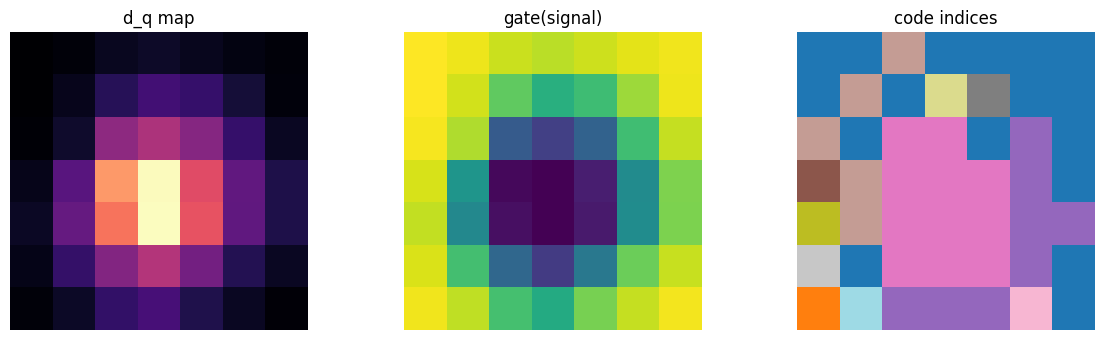

Debug: {'perplexity': 8.902326583862305, 'dq_mean': 0.21004532277584076, 'signal_mean': 0.5505353212356567, 'tau': 0.015339577570557594, 'alpha_softplus': 1.6923978328704834, 'memory_scale': 1.0141087770462036}


In [7]:
def evaluate_clean_noisy(model, loader, config: Config, noise_std: float = 0.5, max_batches: int = 20):
    model.eval()
    clean_correct = 0
    noisy_correct = 0
    total = 0

    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits_clean, _, _ = model(x, feature_noise_std=0.0)
            logits_noisy, _, _ = model(x, feature_noise_std=noise_std)

            clean_correct += (logits_clean.argmax(1) == y).sum().item()
            noisy_correct += (logits_noisy.argmax(1) == y).sum().item()
            total += y.size(0)

    return {
        'clean_acc': clean_correct / max(1, total),
        'noisy_acc': noisy_correct / max(1, total),
    }

metrics = evaluate_clean_noisy(model, testloader, cfg, noise_std=cfg.feature_noise_std, max_batches=10)
print('Test metrics:', metrics)

# inspección visual de un sample
model.eval()
with torch.no_grad():
    x, y = next(iter(testloader))
    x = x[:1].to(device)
    _, _, _, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

    dq = dbg['dq_map'][0, 0].detach().cpu().numpy()
    gate = dbg['signal'][0, 0].detach().cpu().numpy()
    code = dbg['code_map'][0].detach().cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].imshow(dq, cmap='magma'); ax[0].set_title('d_q map'); ax[0].axis('off')
ax[1].imshow(gate, cmap='viridis'); ax[1].set_title('gate(signal)'); ax[1].axis('off')
ax[2].imshow(code, cmap='tab20'); ax[2].set_title('code indices'); ax[2].axis('off')
plt.tight_layout()
plt.show()

print('Debug:', {
    'perplexity': float(dbg['perplexity'].item()),
    'dq_mean': float(dbg['dq_map'].mean().item()),
    'signal_mean': float(dbg['signal'].mean().item()),
    'tau': float(model.gate_tau.item()),
    'alpha_softplus': float(F.softplus(model.gate_alpha).item()),
    'memory_scale': float(model.memory_scale.item()),
})